# Trabajo Práctico - Aprendizaje Automático

## Imports y Seed


In [169]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from six import StringIO  #pip3 install six

from IPython.display import Image, display
import pydotplus

import sklearn
from sklearn.model_selection import cross_validate, StratifiedKFold, ParameterGrid, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [131]:
SEED = 2026

np.random.seed(SEED)
stratifiedKFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

## Separación de Datos de Desarrollo y Control?

In [132]:
df_completo = pd.read_csv('data.csv')

In [133]:
def train_test_split(df):
    buen_pronostico = df[df['target'] == 1]
    p = buen_pronostico.shape[0]/df.shape[0]

    mal_pronostico = df[df['target'] == 0]
    buenos = len(buen_pronostico)/len(df)
    filasBuenas = int(len(df)*buenos*p)
    filasMalas = int(len(df)*p-filasBuenas)
    # buscar como selecciona .sample()
    test = pd.DataFrame(columns=buen_pronostico.columns).astype(buen_pronostico.dtypes)
    test = pd.concat([test, buen_pronostico.sample(n=filasBuenas, random_state=SEED)], ignore_index=False)
    test = pd.concat([test, mal_pronostico.sample(n=filasMalas, random_state=SEED)], ignore_index=False)

    train = df.drop(test.index, axis=0)    
    return train.drop(columns=['target']), train['target'], test.drop(columns=['target']), test['target']

In [134]:
# Definimos el dataset que usaremos para desarrollar el modelo y el dataset de control que usaremos para evaluar el modelo.
X_train, y_train, X_control_NOUSARTONTO, y_control_NOUSARTONTO = train_test_split(df_completo)

df_control_NOUSARTONTO = pd.concat([X_control_NOUSARTONTO, y_control_NOUSARTONTO], axis=1)
df = pd.concat([X_train, y_train], axis=1)

In [135]:
# Legacy code
buen_pronostico = df[df['target'] == 1]
mal_pronostico = df[df['target'] == 0]
buenos = len(buen_pronostico)/500
# buscar como selecciona .sample()
control = pd.DataFrame(columns=buen_pronostico.columns)
control = pd.concat([control, buen_pronostico.sample(n=28)], ignore_index=False)
control = pd.concat([control, mal_pronostico.sample(n=72)], ignore_index=False)

# elegimos mantener las proporciones para no modificar la 
# distribución de los datos inicial, no elegimos random por que puede
# ocurrir que una clase quede subrepresentada y no se evalué correctamente
# el modelo sobre esa clase. 
# No hicimos nada más complejo para evitar data leakage.
control.index

/tmp/ipykernel_142319/2421222922.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  control = pd.concat([control, buen_pronostico.sample(n=28)], ignore_index=False)


Index([493,  59,  27, 104, 450,  80,  39, 437, 327, 122, 419, 312, 385, 258,
       229, 487, 451,  32, 320, 139, 485, 441,  92, 422, 324, 177, 260, 497,
       447, 459, 455,  74,  12, 239, 279, 213, 291, 423, 133, 345,   4, 439,
       181, 492, 448, 449, 331, 166, 134,  55, 421, 406, 339, 227,  81, 365,
        47, 426, 348, 189,   5, 349, 120,  11, 298, 254, 417, 113, 469, 376,
       456, 263, 382,  48,  89,  10, 246, 231, 199, 495, 416, 191,  78,  45,
       131, 274, 473,  42, 389, 399,  65, 347, 410,  58, 156,  41, 184, 197,
       154, 144],
      dtype='int64')

## Ejer 2

### Ejer 2.1

In [ ]:
def train_tree(X_tr: np.ndarray, y_tr: np.ndarray, tree_params={}) -> DecisionTreeClassifier:
    arbol = DecisionTreeClassifier(**tree_params, random_state=SEED)
    arbol.fit(X_tr, y_tr)

    return arbol

def dibujar_arbol(clf, c_name, f_name):
    # modo de uso: dibujar_arbol(arbol, nombres_de_clases, nombres_de_features)
    if(c_name is None or f_name is None):
        return "Debe especificar los nombres de las clases y de las features"
    
    dot_data = StringIO()
    sklearn.tree.export_graphviz(clf, out_file = dot_data,
                    filled = True,
                    class_names = c_name,
                    feature_names = f_name,
                    special_characters = True)

    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    display(Image(graph.create_png()))

In [ ]:
X_train, y_train, X_test, y_test = train_test_split(df)

tree_1 = train_tree(X_train, y_train, tree_params={'max_depth': 3})

print("Score sobre el dataset de entrenamiento: ", tree_1.score(X_train, y_train))
print("Score sobre el dataset de prueba: ", tree_1.score(X_test, y_test))


Score sobre el dataset de entrenamiento:  0.8326848249027238
Score sobre el dataset de prueba:  0.6764705882352942


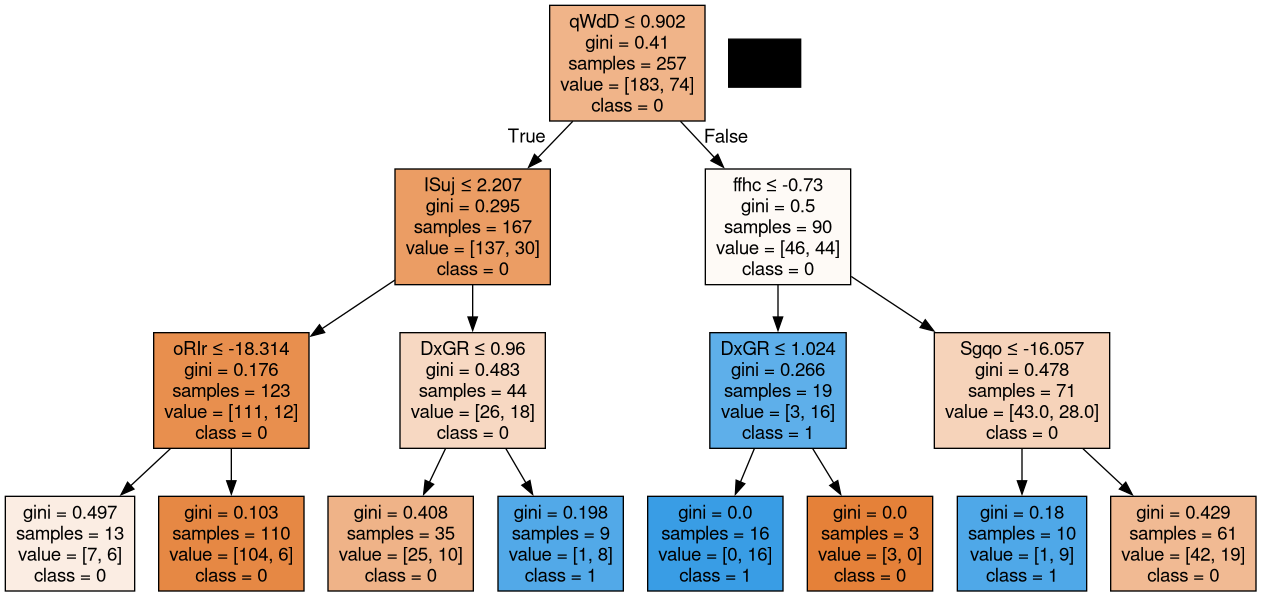

In [ ]:
dibujar_arbol(tree_1, c_name=['0','1'], f_name=df.drop(columns=['target']).columns)

### Ejer 2.2

In [181]:
# FALTA AÑADIR LAS AUCROC Y ESO
tree_2 = DecisionTreeClassifier(max_depth=3, random_state=SEED)

resultados_folds = []

y_global_true = np.empty(len(y_train))
y_global_pred = np.empty(len(y_train))

for fold_idx, (train_index, val_index) in enumerate(stratifiedKFold.split(X_train, y_train)):

    kf_X_train, kf_X_test = X_train.iloc[train_index], X_train.iloc[val_index]
    kf_y_train, kf_y_test = y_train.iloc[train_index], y_train.iloc[val_index]

    tree_2.fit(kf_X_train, kf_y_train)

    y_pred_train = tree_2.predict(kf_X_train)

    y_pred_test = tree_2.predict(kf_X_test)

    y_global_true[val_index] = kf_y_test
    y_global_pred[val_index] = y_pred_test


    resultados_folds.append({
        'Permutación': str(fold_idx),
        'Accuracy (train)': accuracy_score(kf_y_train, y_pred_train),
        'Accuracy (validation)': accuracy_score(kf_y_test, y_pred_test),
    })

df_tabla = pd.DataFrame(resultados_folds)

promedios = df_tabla.drop(columns=['Permutación']).mean()
df_tabla.loc[len(df_tabla)] = ['Promedios'] + list(promedios)


df_tabla.loc[len(df_tabla)] = [
    'Global',
    '(NO)',
    accuracy_score(y_global_true, y_global_pred)
]

df_tabla

,Permutación,Accuracy (train),Accuracy (validation)
0,0,0.868293,0.711538
1,1,0.858537,0.673077
2,2,0.830097,0.803922
3,3,0.854369,0.705882
4,4,0.849515,0.666667
5,Promedios,0.852162,0.712217
6,Global,(NO),0.712062


### Ejer 2.3

In [182]:
def grid_search_tree(X_train, y_train, param_grid={'max_depth': [3,5,None], 'criterion': ['gini', 'entropy']}, metric='accuracy'):
    grid = ParameterGrid(param_grid)
    res = []
    
    for params in grid:
        current_tree = DecisionTreeClassifier(**params, random_state=SEED)
        
        cv_results = cross_validate(
            current_tree, 
            X_train, 
            y_train, 
            cv=stratifiedKFold, 
            scoring=metric, 
            return_train_score=True 
        )
        
        fila = {}
        for param_name, param_value in params.items():
            if param_name == 'max_depth' and param_value is None:
                fila[param_name] = 'Infinito'
            else:
                fila[param_name] = param_value
                
        fila[f'{metric} (training)'] = cv_results['train_score'].mean()
        fila[f'{metric} (validación)'] = cv_results['test_score'].mean()
        
        res.append(fila)

    return pd.DataFrame(res)

### DUDA: Nos dice que usemos promedios pero eso no estaba mal? ScikitLearn en sus funciones hace promedio para cualquier score, incluso metricas no lineales

In [187]:
grid_search_tree(X_train, y_train)

,criterion,max_depth,accuracy (training),accuracy (validación)
0,gini,3,0.852162,0.712217
1,gini,5,0.956235,0.708220
2,gini,Infinito,1.000000,0.673228
3,entropy,3,0.814217,0.673303
4,entropy,5,0.931925,0.700302
5,entropy,Infinito,1.000000,0.708296


## Ejer 3

#### Ejemplo

In [ ]:
# Al usar RandomizedSearchCV, ya realiza todo lo que hicimos antes, ejemplo con tree:
random_search_tree = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=SEED),
    param_distributions={
        'max_depth': [3, 5, 6, 7, None],
        'criterion': ['gini', 'entropy']
    }, # restringe el espacio de búsqueda a estos valores (prueba combinaciones dentro de los rangos de estos valores, en este caso son discretos así que solo prueba combinaciones de estos)
    n_iter=10, # combinaciones aleatorias a probar
    scoring='accuracy',
    cv=stratifiedKFold,
    random_state=SEED,
    return_train_score=True,
    n_jobs=-1 # esto usa todos los nucleos de CPU, stonks
)

random_search_tree.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...om_state=2026)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",2026
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Wher

## Ejer 4

## Viendo cosas de varianza

In [142]:
std_total = df.drop(columns=['target']).std()
media_total = df.drop(columns=['target']).mean()
cv_total = (std_total / media_total).abs()

var_total = df.drop(columns=['target']).var()
var_por_clase = df.groupby('target').var().T

df_stats = pd.DataFrame({
    'Varianza_Total': var_total,
    'CV_Total': cv_total,
    'Varianza_Clase_0': var_por_clase[0], # Ni idea si sirve de algo para la clase, pero ya que estoy
    'Varianza_Clase_1': var_por_clase[1]
})

df_stats.sort_values(by='CV_Total', ascending=True)

,Varianza_Total,CV_Total,Varianza_Clase_0,Varianza_Clase_1
vrzO,11.568771,2.861303,10.307896,14.749103
Sgqo,180.253282,2.868825,158.166138,211.281727
qbak,215.859527,2.887304,224.136420,196.933893
XrKM,14.765521,3.137730,13.662336,17.033993
GLoy,247.393089,3.308102,248.830661,246.127942
...,...,...,...,...
ZBdc,0.913269,665.106613,0.880131,0.984546
VbZF,1.122384,744.075558,1.164044,0.992927
BxJD,0.968988,2542.921214,1.026322,0.832474
Kasv,1.034094,3228.527419,1.046284,1.001047


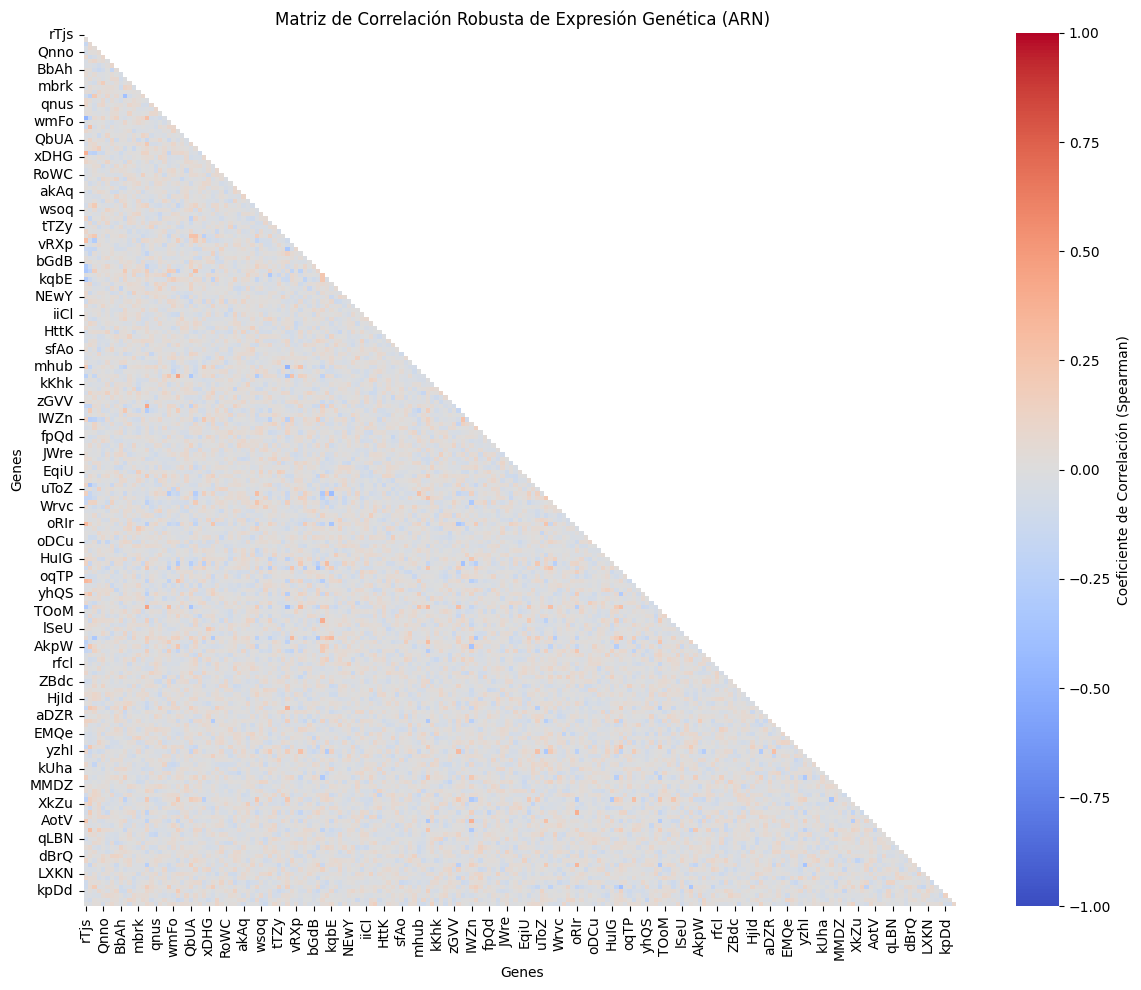

Series([], dtype: float64)


In [143]:
X = df.drop(columns=['target'])

matriz_corr = X.corr(method='spearman')

mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_corr, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    cbar_kws={'label': 'Coeficiente de Correlación (Spearman)'}
)
plt.title('Matriz de Correlación Robusta de Expresión Genética (ARN)')
plt.xlabel('Genes')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()

correlaciones_apiladas = matriz_corr.mask(mask).stack()
correlaciones_fuertes = correlaciones_apiladas[abs(correlaciones_apiladas) > 0.5].sort_values(ascending=False)
print(correlaciones_fuertes)